In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
G = nx.read_edgelist(
    "../data/processed/orkut_largest_community.edgelist",
    nodetype=int
)

print(
    G.number_of_nodes(),
    G.number_of_edges()
)

4785 119891


In [3]:
real_clustering = nx.average_clustering(G)

real_path = nx.average_shortest_path_length(G)

print("Clusterização:", real_clustering)
print("Caminho médio:", real_path)

Clusterização: 0.3129664530934682
Caminho médio: 3.283968854733472


In [4]:
n = G.number_of_nodes()
m = G.number_of_edges()

G_random = nx.gnm_random_graph(
    n,
    m,
    seed=42
)

In [5]:
random_clustering = nx.average_clustering(
    G_random
)

random_path = nx.average_shortest_path_length(
    G_random
)

print("Clusterização aleatória:", random_clustering)
print("Caminho médio aleatório:", random_path)

Clusterização aleatória: 0.01047905581373095
Caminho médio aleatório: 2.575137169177649


In [6]:
sigma = (
    (real_clustering / random_clustering)
    /
    (real_path / random_path)
)

print(
    "Small-World Sigma:",
    sigma
)

Small-World Sigma: 23.419465139315363


In [7]:
degrees = [
    d
    for _, d in G.degree()
]

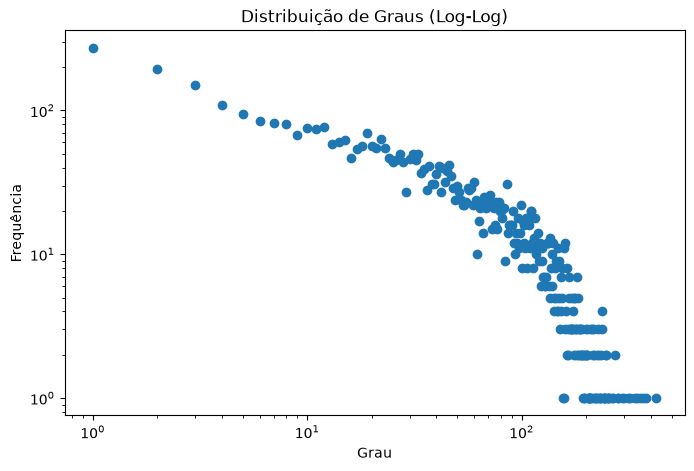

In [8]:
degree_counts = np.bincount(degrees)

k = np.arange(
    len(degree_counts)
)

plt.figure(figsize=(8,5))

plt.loglog(
    k[1:],
    degree_counts[1:],
    marker='o',
    linestyle='None'
)

plt.xlabel("Grau")
plt.ylabel("Frequência")

plt.title(
    "Distribuição de Graus (Log-Log)"
)

plt.savefig(
    "../figures/powerlaw_loglog.png",
    dpi=300
)

plt.show()

In [9]:
xmin = min(
    d
    for d in degrees
    if d > 0
)

alpha = 1 + len(degrees) / sum(
    np.log(
        d/xmin
    )
    for d in degrees
    if d > 0
)

print(
    "Alpha:",
    alpha
)

Alpha: 1.3128276496312596


In [10]:
print("=== SMALL WORLD ===")

print(
    "Sigma:",
    sigma
)

print()

print("=== POWER LAW ===")

print(
    "Alpha:",
    alpha
)

=== SMALL WORLD ===
Sigma: 23.419465139315363

=== POWER LAW ===
Alpha: 1.3128276496312596
